# Encoder-Only Transformer (Sentiment Classification)

A minimal BERT-style encoder that reads a whole review at once and predicts a
sentiment label (`positive` / `negative`). Everything is tiny on purpose:
small vocab, `d_model = 8`, one attention head, one encoder block.


- **bidirectional attention** — every token sees the whole sentence 
- sequence classification (one label per review) 
- `Linear(d_model, num_classes)` on a pooled vector 
- `<CLS>` at position 0 summarizes the sequence 

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
# =====================================================
# Vocabulary
#
# <CLS> sits at the front of every review. After the encoder runs,
# its output vector is used as the summary of the whole sentence
# and fed to the classification head.
# <PAD> fills short reviews up to a common length.
# <UNK> stands in for any word outside this vocabulary, so free-text
# inference degrades instead of raising KeyError.
# =====================================================
token_to_id = {
    "<CLS>": 0,
    "<PAD>": 1,
    "<UNK>": 2,
    "the": 3,
    "movie": 4,
    "was": 5,
    "great": 6,
    "terrible": 7,
    "i": 8,
    "loved": 9,
    "hated": 10,
    "it": 11,
    "a": 12,
    "waste": 13,
    "of": 14,
    "time": 15,
    "absolutely": 16,
    "amazing": 17,
    "boring": 18,
    "and": 19,
    "dull": 20,
    "best": 21,
    "ever": 22,
    "worst": 23,
    "not": 24
}

id_to_token = {v: k for k, v in token_to_id.items()}

# label ids
label_to_id = {"negative": 0, "positive": 1}
id_to_label = {v: k for k, v in label_to_id.items()}

vocab_size = len(token_to_id)
num_classes = len(label_to_id)
d_model = 8
max_len = 12

In [3]:
# =====================================================
# Training Reviews
#
# Each review starts with <CLS> and carries a sentiment label.
# Unlike the decoder model there is no next-token target -- the
# whole sentence maps to a single label.
# =====================================================
train_reviews = [
    (["<CLS>", "the", "movie", "was", "great"],                 "positive"),
    (["<CLS>", "i", "loved", "it"],                             "positive"),
    (["<CLS>", "absolutely", "amazing", "movie"],               "positive"),
    (["<CLS>", "the", "best", "movie", "ever"],                 "positive"),
    (["<CLS>", "i", "loved", "the", "movie"],                   "positive"),
    (["<CLS>", "the", "movie", "was", "terrible"],              "negative"),
    (["<CLS>", "i", "hated", "it"],                             "negative"),
    (["<CLS>", "a", "waste", "of", "time"],                     "negative"),
    (["<CLS>", "boring", "and", "dull"],                        "negative"),
    (["<CLS>", "the", "worst", "movie", "ever"],                "negative"),
    (["<CLS>", "the", "movie", "was", "not", "great"],          "negative"),
    (["<CLS>", "the", "movie", "was", "not", "amazing"],        "negative"),
]

In [4]:
# =====================================================
# Held-out Reviews
#
# Same vocabulary, word combinations the model never trains on.
# These are the only rows that say anything about generalization:
# accuracy on train_reviews measures how well 12 examples were
# memorized, and with 500 full-batch epochs the answer is "perfectly".
#
# The last one is the hard case -- during training "not" only ever
# appears in front of a positive word.
# =====================================================
val_reviews = [
    (["<CLS>", "absolutely", "the", "best"],                    "positive"),
    (["<CLS>", "i", "loved", "the", "best", "movie"],           "positive"),
    (["<CLS>", "the", "movie", "was", "amazing"],               "positive"),
    (["<CLS>", "a", "terrible", "waste", "of", "time"],         "negative"),
    (["<CLS>", "i", "hated", "the", "boring", "movie"],         "negative"),
    (["<CLS>", "the", "movie", "was", "boring", "and", "dull"], "negative"),
    (["<CLS>", "the", "movie", "was", "not", "boring"],         "positive"),
]

In [5]:
# =====================================================
# Build Training Data
# X = padded token ids   (batch, max_len)
# Y = sentiment label     (batch,)
#
# Words outside the vocabulary become <UNK> rather than a KeyError.
# =====================================================
pad_id = token_to_id["<PAD>"]
unk_id = token_to_id["<UNK>"]

def encode(words):
    ids = [token_to_id.get(w, unk_id) for w in words]
    ids = ids[:max_len]
    ids = ids + [pad_id] * (max_len - len(ids))
    return ids

def build(dataset):
    X = torch.tensor([encode(words) for words, _ in dataset])
    Y = torch.tensor([label_to_id[label] for _, label in dataset])
    return X, Y

X_train, Y_train = build(train_reviews)
X_val, Y_val = build(val_reviews)

print("Train input", tuple(X_train.shape))
print(X_train)

print("\nTrain labels")
print(Y_train)

print("\nHeld-out input", tuple(X_val.shape))
print(X_val)

print("\nHeld-out labels")
print(Y_val)

Train input (12, 12)
tensor([[ 0,  3,  4,  5,  6,  1,  1,  1,  1,  1,  1,  1],
        [ 0,  8,  9, 11,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 0, 16, 17,  4,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 0,  3, 21,  4, 22,  1,  1,  1,  1,  1,  1,  1],
        [ 0,  8,  9,  3,  4,  1,  1,  1,  1,  1,  1,  1],
        [ 0,  3,  4,  5,  7,  1,  1,  1,  1,  1,  1,  1],
        [ 0,  8, 10, 11,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 0, 12, 13, 14, 15,  1,  1,  1,  1,  1,  1,  1],
        [ 0, 18, 19, 20,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 0,  3, 23,  4, 22,  1,  1,  1,  1,  1,  1,  1],
        [ 0,  3,  4,  5, 24,  6,  1,  1,  1,  1,  1,  1],
        [ 0,  3,  4,  5, 24, 17,  1,  1,  1,  1,  1,  1]])

Train labels
tensor([1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0])

Held-out input (7, 12)
tensor([[ 0, 16,  3, 21,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 0,  8,  9,  3, 21,  4,  1,  1,  1,  1,  1,  1],
        [ 0,  3,  4,  5, 17,  1,  1,  1,  1,  1,  1,  1],
        [ 0, 12,  7, 13, 

In [6]:
# =====================================================
# Positional Encoding
# (identical to the decoder model -- position still matters)
# =====================================================
class PositionEncoding(nn.Module):

    def __init__(self, d_model, max_len):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2)
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe)

    def forward(self, word_embeddings):
        seq_len = word_embeddings.size(-2)
        return word_embeddings + self.pe[:seq_len]

In [7]:
# =====================================================
# Single Head Bidirectional Attention
#
# The key difference from the decoder: there is NO causal mask.
# Every token attends to every other token, so the <CLS> summary
# can look at the entire review at once.
#
# We still mask out <PAD> positions so padding never contributes
# to the attention weights.
# =====================================================
class Attention(nn.Module):

    def __init__(self, d_model):
        super().__init__()

        self.d_model = d_model

        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, pad_mask=None):

        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        scores = torch.matmul(Q, K.transpose(-2, -1))
        scores = scores / math.sqrt(self.d_model)

        # pad_mask: (batch, seq) with True where token is <PAD>.
        # Expand to (batch, 1, seq) so those key positions are ignored.
        if pad_mask is not None:
            scores = scores.masked_fill(
                pad_mask.unsqueeze(1), -1e9
            )

        attention = F.softmax(scores, dim=-1)

        output = torch.matmul(attention, V)

        return output

In [8]:
# =====================================================
# Encoder Block
# (same shape as the decoder block, just bidirectional attention)
# =====================================================
class EncoderBlock(nn.Module):

    def __init__(self, d_model):
        super().__init__()

        self.attention = Attention(d_model)

        self.norm1 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, 16),
            nn.ReLU(),
            nn.Linear(16, d_model),
        )

        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, pad_mask=None):

        attn = self.attention(x, pad_mask)

        x = self.norm1(x + attn)

        ff = self.ff(x)

        x = self.norm2(x + ff)

        return x

In [9]:
# =====================================================
# Encoder Only Transformer (Classifier)
#
# 1. embed + add position
# 2. run the encoder block (bidirectional)
# 3. take the <CLS> vector at position 0 as the sentence summary
# 4. project it to class logits
# =====================================================
class EncoderOnlyTransformer(nn.Module):

    def __init__(self, vocab_size, d_model, max_len, num_classes, pad_id):
        super().__init__()
        self.pad_id = pad_id
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.position = PositionEncoding(d_model, max_len)
        self.encoder = EncoderBlock(d_model)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        pad_mask = (x == self.pad_id)   # (batch, seq)

        x = self.embedding(x)
        x = self.position(x)
        x = self.encoder(x, pad_mask)

        cls = x[:, 0]                   # (batch, d_model) -- the <CLS> summary
        logits = self.fc(cls)           # (batch, num_classes)
        return logits

In [10]:
# =====================================================
# Create Model
#
# Seeded on purpose. With only 12 training reviews the held-out
# result swings a lot between initializations -- unseeded, the
# numbers below change every time the notebook is re-run.
# =====================================================
torch.manual_seed(0)

model = EncoderOnlyTransformer(
    vocab_size=vocab_size,
    d_model=d_model,
    max_len=max_len,
    num_classes=num_classes,
    pad_id=pad_id,
)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
)

In [ ]:
# =====================================================
# Parameter Count
#
# named_parameters() yields exactly the tensors the optimizer updates.
# The position encoding is missing from this list on purpose -- it is a
# registered buffer, so it has no gradient and is not learned.
#
# Compare the totals against the table in the first cell.
# =====================================================
def parameter_report(model):
    print(f"{'parameter':28s} {'shape':12s} {'count':>7s}")
    print("-" * 51)

    total = 0
    for name, p in model.named_parameters():
        print(f"{name:28s} {str(tuple(p.shape)):12s} {p.numel():7d}")
        total += p.numel()

    buffers = sum(b.numel() for b in model.buffers())

    print("-" * 51)
    print(f"{'trainable total':28s} {'':12s} {total:7d}")
    print(f"{'buffers (not trained)':28s} {'':12s} {buffers:7d}")

    return total


total_params = parameter_report(model)

# The same number derived from the hyperparameters alone.
d_ff = 16

expected = (
    vocab_size * d_model                     # embedding
    + 3 * d_model * d_model                  # Wq, Wk, Wv -- no bias, no Wo
    + 2 * d_model                            # norm1
    + (d_model * d_ff + d_ff)                # feed-forward in
    + (d_ff * d_model + d_model)             # feed-forward out
    + 2 * d_model                            # norm2
    + (d_model * num_classes + num_classes)  # classification head
)

print()
print(f"formula = {expected}   model = {total_params}   match = {expected == total_params}")

In [11]:
# =====================================================
# Training
#
# Training loss is not a progress bar for learning, it is a progress
# bar for memorization. Held-out accuracy is measured alongside it so
# the gap between the two is visible while training runs.
# =====================================================
def accuracy(X, Y):
    was_training = model.training
    model.eval()

    with torch.no_grad():
        preds = model(X).argmax(dim=-1)

    model.train(was_training)
    return (preds == Y).float().mean().item()

epochs = 500
history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    logits = model(X_train)

    loss = criterion(logits, Y_train)

    loss.backward()

    optimizer.step()

    if epoch % 10 == 0:
        history.append((
            epoch,
            loss.item(),
            accuracy(X_train, Y_train),
            accuracy(X_val, Y_val),
        ))

    if epoch % 50 == 0:
        _, l, train_acc, val_acc = history[-1]
        print(f"Epoch {epoch:4d}  loss = {l:.4f}   "
              f"train acc = {train_acc:.2f}   held-out acc = {val_acc:.2f}")

Epoch    0  loss = 0.7314   train acc = 0.58   held-out acc = 0.43
Epoch   50  loss = 0.1382   train acc = 0.92   held-out acc = 0.71
Epoch  100  loss = 0.0007   train acc = 1.00   held-out acc = 0.71
Epoch  150  loss = 0.0003   train acc = 1.00   held-out acc = 0.71
Epoch  200  loss = 0.0002   train acc = 1.00   held-out acc = 0.71
Epoch  250  loss = 0.0002   train acc = 1.00   held-out acc = 0.71
Epoch  300  loss = 0.0001   train acc = 1.00   held-out acc = 0.71
Epoch  350  loss = 0.0001   train acc = 1.00   held-out acc = 0.71
Epoch  400  loss = 0.0001   train acc = 1.00   held-out acc = 0.71
Epoch  450  loss = 0.0001   train acc = 1.00   held-out acc = 0.71


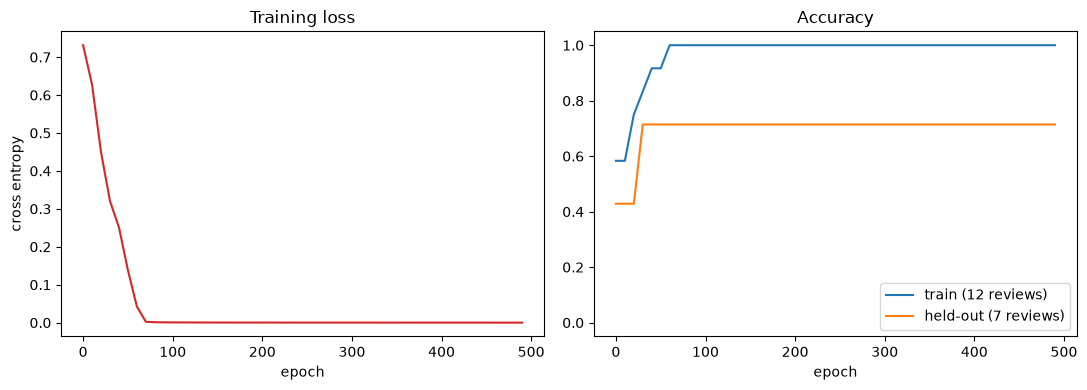

In [12]:
# =====================================================
# Learning Curves
#
# Left: loss on the 12 training reviews collapses to ~0.
# Right: the two accuracy lines separate, and the gap between them is
# the overfitting. More epochs do not close it -- only more data (or
# a smaller model) would.
# =====================================================
steps      = [h[0] for h in history]
losses     = [h[1] for h in history]
train_accs = [h[2] for h in history]
val_accs   = [h[3] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(steps, losses, color="tab:red")
ax1.set_title("Training loss")
ax1.set_xlabel("epoch")
ax1.set_ylabel("cross entropy")

ax2.plot(steps, train_accs, label="train (12 reviews)")
ax2.plot(steps, val_accs, label="held-out (7 reviews)")
ax2.set_ylim(-0.05, 1.05)
ax2.set_title("Accuracy")
ax2.set_xlabel("epoch")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [13]:
# =====================================================
# Predictions
#
# Two tables. The first is the memorization check, the second is the
# one that actually matters.
# =====================================================
def report(name, dataset, X, Y):
    model.eval()

    with torch.no_grad():
        preds = model(X).argmax(dim=-1)

    correct = (preds == Y).sum().item()
    total = len(Y)
    print(f"{name}  --  {correct}/{total} correct "
          f"(accuracy = {correct / total:.2f})\n")

    for (words, true_label), pred in zip(dataset, preds):
        text = " ".join(w for w in words if w != "<CLS>")
        label = id_to_label[pred.item()]
        mark = "OK " if label == true_label else "XX "
        print(f"  {mark}{text:34s} -> {label:8s} (true: {true_label})")

    print()

report("Training reviews", train_reviews, X_train, Y_train)
report("Held-out reviews", val_reviews, X_val, Y_val)

Training reviews  --  12/12 correct (accuracy = 1.00)

  OK the movie was great                -> positive (true: positive)
  OK i loved it                         -> positive (true: positive)
  OK absolutely amazing movie           -> positive (true: positive)
  OK the best movie ever                -> positive (true: positive)
  OK i loved the movie                  -> positive (true: positive)
  OK the movie was terrible             -> negative (true: negative)
  OK i hated it                         -> negative (true: negative)
  OK a waste of time                    -> negative (true: negative)
  OK boring and dull                    -> negative (true: negative)
  OK the worst movie ever               -> negative (true: negative)
  OK the movie was not great            -> negative (true: negative)
  OK the movie was not amazing          -> negative (true: negative)

Held-out reviews  --  5/7 correct (accuracy = 0.71)

  OK absolutely the best                -> positive (true: posi

In [14]:
# =====================================================
# Inference on free text
#
# Unknown words collapse to <UNK>: the model no longer crashes on
# them, but it has nothing useful to say about them either. Whatever
# label comes back is driven entirely by the words it does know.
# =====================================================
def predict_sentiment(text):
    words = ["<CLS>"] + text.lower().split()
    unknown = [w for w in words[1:] if w not in token_to_id]

    ids = torch.tensor([encode(words)])

    model.eval()
    with torch.no_grad():
        logits = model(ids)
        probs = F.softmax(logits, dim=-1)[0]
        pred = probs.argmax().item()

    print(f"Review    : {text}")
    if unknown:
        print(f"Unknown   : {', '.join(unknown)}  ->  <UNK>")
    print(f"Sentiment : {id_to_label[pred]}  "
          f"(neg={probs[0]:.2f}, pos={probs[1]:.2f})\n")

predict_sentiment("the movie was not great")
predict_sentiment("i hated the boring movie")
predict_sentiment("absolutely the best")
predict_sentiment("the film was fantastic")
predict_sentiment("what a stunning masterpiece")

Review    : the movie was not great
Sentiment : negative  (neg=1.00, pos=0.00)

Review    : i hated the boring movie
Sentiment : negative  (neg=1.00, pos=0.00)

Review    : absolutely the best
Sentiment : positive  (neg=0.00, pos=1.00)

Review    : the film was fantastic
Unknown   : film, fantastic  ->  <UNK>
Sentiment : negative  (neg=1.00, pos=0.00)

Review    : what a stunning masterpiece
Unknown   : what, stunning, masterpiece  ->  <UNK>
Sentiment : negative  (neg=1.00, pos=0.00)



## Shapes at every step

| Stage | Tensor | Shape |
|---|---|---|
| input | `X` | `(batch, seq)` |
| after embedding | word vectors | `(batch, seq, 8)` |
| after position encoding | positioned vectors | `(batch, seq, 8)` |
| attention scores | `Q @ K.T / sqrt(8)` | `(batch, seq, seq)` |
| after encoder block | contextualized vectors | `(batch, seq, 8)` |
| `<CLS>` pooled vector | `x[:, 0]` | `(batch, 8)` |
| after `fc` | logits | `(batch, 2)` — one score per class |


## Counting the parameters

A parameter is any tensor the optimizer updates. Three rules cover almost
every layer:

| Layer | Params |
|---|---|
| `nn.Embedding(n, d)` | `n * d` |
| `nn.Linear(in, out)` | `in * out + out` (the `+ out` is the bias; `bias=False` drops it) |
| `nn.LayerNorm(d)` | `2 * d` (a scale and a shift per feature) |

Anything registered with `register_buffer` -- the sinusoidal position table
here -- is **not** a parameter. It is computed once, never receives a
gradient, and never appears in `model.parameters()`.

Applying those rules to this model (`vocab_size = 25`, `d_model = 8`,
`d_ff = 16`, `num_classes = 2`):

| Module | Shape(s) | Formula | Params |
|---|---|---|---|
| `embedding` | `(25, 8)` | `vocab_size * d_model` | 200 |
| `position.pe` | `(12, 8)` | buffer -- not trainable | 0 |
| `attention.Wq/Wk/Wv` | `3 x (8, 8)` | `3 * d_model^2` (no bias) | 192 |
| `encoder.norm1` | `(8,) + (8,)` | `2 * d_model` | 16 |
| `encoder.ff[0]` | `(16, 8) + (16,)` | `d_model * d_ff + d_ff` | 144 |
| `encoder.ff[2]` | `(8, 16) + (8,)` | `d_ff * d_model + d_model` | 136 |
| `encoder.norm2` | `(8,) + (8,)` | `2 * d_model` | 16 |
| `fc` | `(2, 8) + (2,)` | `d_model * num_classes + num_classes` | 18 |
| **Total** | | | **722** |

The cell after the model is built prints this same breakdown from
`named_parameters()`, so the table can be checked rather than trusted.

### How it scales

Collapsing the block into one expression:

```
block = 3 * d_model^2          # Wq, Wk, Wv
      + 2 * d_model * d_ff     # feed-forward weights
      + d_ff + d_model         # feed-forward biases
      + 4 * d_model            # two LayerNorms
```

Two things follow, and they are the reason large models are shaped the way
they are:

- **Width costs quadratically, depth costs linearly.** Every term above is
  either `d_model^2` or `d_model * d_ff`, and the standard choice is
  `d_ff = 4 * d_model`, which makes a full block roughly `12 * d_model^2`.
  Doubling `d_model` quadruples the block; adding a second layer only doubles
  it. This is the same quadratic noted in the width sweep at the end of the
  notebook.
- **The embedding dominates only while the model is tiny.** Here it is
  200 of 722 params (28%) because `d_model^2 = 64` is small. Real models
  invert this: the embedding grows as `vocab_size * d_model` (linear in
  width) while the stack grows as `n_layers * 12 * d_model^2`.

Two caveats about this specific implementation:

- **There is no output projection `Wo`.** A standard attention block ends
  with `Linear(d_model, d_model)` after concatenating the heads, which would
  add another `d_model^2 = 64` params and make the attention term the usual
  `4 * d_model^2`. With a single head it is a simplification the model can
  absorb; with multiple heads `Wo` is what mixes them, so it stops being
  optional.
- **A classification head is negligible.** `fc` is 18 params because it maps
  to 2 classes. Swap it for the decoder-only model's `Linear(d_model,
  vocab_size)` head and it becomes `8 * 25 + 25 = 225` -- about a third of
  the whole model -- which is why large language models tie the output head
  to the embedding matrix instead of learning a second copy.


## How wide should `d_model` be?

`d_model = 8` was picked to keep the tensors readable, not because it is right.
The sweep below trains the whole model from scratch at a range of widths and
reports accuracy on both splits, so the choice is measured rather than assumed.

**Read the two accuracy columns as a diagnostic, not a score.** They point at
opposite fixes:

| Symptom | Diagnosis | Fix |
|---|---|---|
| train acc low | underfitting -- the model cannot represent the task | more capacity: `d_model`, layers, heads |
| train acc ~1.00, held-out far below | overfitting -- it memorized the rows | more **data**, regularization, or a *smaller* model |

Everything above `d_model = 4` lands in the second row, which is why widening
barely moves the held-out number: 12 reviews, not model width, is the ceiling.

Two things worth noticing in the output:

- **The widest models score worse on the training set too.** That is not a
  capacity limit -- it is `lr = 0.01` being too large for them. At
  `d_model = 64` with `lr = 0.001` and 3000 epochs, train accuracy returns to
  1.00 and held-out accuracy still only reaches ~0.71. Wider models need a
  smaller learning rate and more steps; this is what learning-rate warmup exists
  to handle.
- **Cost grows quadratically.** Attention is `4 * d_model^2` per block and the
  feed-forward is `2 * d_model * d_ff`, so doubling the width roughly quadruples
  the work per block, while adding a *layer* is only linear.

The real reason to widen this model comes in the multi-head version, not from
this table: `d_model` must divide evenly by `num_heads`, and each head only gets
`d_head = d_model / num_heads` dimensions to work with. At `d_model = 8` with two
heads that is 4 dimensions per head, which is already thin -- production models
almost universally hold `d_head = 64` and vary the head count instead.